### 1.DATA LOADING AND SUMMARY STATISTICS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (ttest_ind, mannwhitneyu, shapiro, normaltest,
                          f_oneway, kruskal, pointbiserialr)
SEED = 42

sns.set()

#import data
df = pd.read_csv(r"Housing.csv")
# working copy
b = df.copy()

#Summary Statistics
display(b.info())

print("\n=== MISSING VALUE SUMMARY ===")
print(df.isna().sum().to_markdown(headers=["Column", "Null Count"]))

print("\n=== DUPLICATED ROWS ===")
print(df.duplicated().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None


=== MISSING VALUE SUMMARY ===
| Column           |   Null Count |
|:-----------------|-------------:|
| price            |            0 |
| area             |            0 |
| bedrooms         |            0 |
| bathrooms        |            0 |
| stories          |            0 |
| mainroad         |            0 |
| guestroom        |            0 |
| basement         |            0 |
| hotwaterheating  |            0 |
| airconditioning  |            0 |
| parking          |            0 |
| prefarea         |            0 |
| furnishingstatus |            0 |

=== DUPLICATED ROWS ===
0


In [2]:
#Type Casting (Boolean to Binary)
binary_cols = ["mainroad","guestroom","basement","hotwaterheating",
               "airconditioning","prefarea"]
for col in binary_cols:
    b[col] = (b[col].str.lower() == "yes").astype(int)

b.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [3]:
#Checking columns for missing values
missing_pct = (df.isna().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    "missing count": df.isna().sum(),
    "percentage": missing_pct
}).sort_values("percentage", ascending=False)
missing_info


,missing count,percentage
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


### 2. FEATURE ENGINEERING

In [4]:
# Log-transform price and area (right-skewed)
b["PriceLog"]     = np.log1p(b["price"])
b["AreaLog"]      = np.log1p(b["area"])

# Price per sq-ft
b["PricePerSqFt"] = b["price"] / b["area"]

# Amenity score: sum of all binary feature columns
b["AmenityScore"] = b[binary_cols].sum(axis=1)

# Room density (bedrooms + bathrooms per story)
b["RoomDensity"]  = (b["bedrooms"] + b["bathrooms"]) / b["stories"]

# Furnishing as ordered numeric
furnish_map = {"unfurnished": 0, "semi-furnished": 1, "furnished": 2}
b["FurnishNum"] = b["furnishingstatus"].map(furnish_map)

print(f"Shape after engineering: {b.shape}")
display(b.head())


Shape after engineering: (545, 19)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,PriceLog,AreaLog,PricePerSqFt,AmenityScore,RoomDensity,FurnishNum
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,16.403275,8.912069,1792.452830,3,2.0,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,16.321037,9.100637,1367.187500,2,2.0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,16.321037,9.206433,1229.919679,3,2.5,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,16.318175,8.922792,1628.666667,4,3.0,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,16.250001,8.912069,1537.735849,4,2.5,2


### 3. Descriptive Statistics

In [5]:
numeric_cols = ["price","area","bedrooms","bathrooms","stories",
                "parking","PriceLog","AreaLog","PricePerSqFt","AmenityScore"]

desc = b[numeric_cols].describe().T
desc["variance"] = b[numeric_cols].var()
desc["skewness"] = b[numeric_cols].skew()
desc["kurtosis"] = b[numeric_cols].kurtosis()
desc["cv"]       = desc["std"] / desc["mean"]
display(desc.round(3))

print("\n── Price by Furnishing Status ──")
display(b.groupby("furnishingstatus")["price"]
         .agg(["mean","median","std","min","max"]).round(0))

print("\n── Price by Number of Bedrooms ──")
display(b.groupby("bedrooms")["price"]
         .agg(["mean","median","std","count"]).round(0))


,count,mean,std,min,25%,50%,75%,max,variance,skewness,kurtosis,cv
price,545.0,4766729.248,1870439.616,1750000.000,3430000.000,4340000.000,5740000.000,1.330000e+07,3.498544e+12,1.212,1.960,0.392
area,545.0,5150.541,2170.141,1650.000,3600.000,4600.000,6360.000,1.620000e+04,4.709512e+06,1.321,2.751,0.421
bedrooms,545.0,2.965,0.738,1.000,2.000,3.000,3.000,6.000000e+00,5.450000e-01,0.496,0.728,0.249
bathrooms,545.0,1.286,0.502,1.000,1.000,1.000,2.000,4.000000e+00,2.520000e-01,1.589,2.165,0.391
stories,545.0,1.806,0.867,1.000,1.000,2.000,2.000,4.000000e+00,7.530000e-01,1.082,0.679,0.480
parking,545.0,0.694,0.862,0.000,0.000,0.000,1.000,3.000000e+00,7.420000e-01,0.842,-0.573,1.242
PriceLog,545.0,15.307,0.372,14.375,15.048,15.283,15.563,1.640300e+01,1.390000e-01,0.141,-0.137,0.024
AreaLog,545.0,8.467,0.398,7.409,8.189,8.434,8.758,9.693000e+00,1.590000e-01,0.134,-0.214,0.047
PricePerSqFt,545.0,993.327,346.537,270.396,745.370,952.381,1184.615,2.640000e+03,1.200879e+05,0.815,1.097,0.349
AmenityScore,545.0,1.983,1.195,0.000,1.000,2.000,3.000,5.000000e+00,1.428000e+00,0.473,-0.293,0.602



── Price by Furnishing Status ──


,mean,median,std,min,max
furnishingstatus,,,,,
furnished,5495696.0,5075000.0,2117857.0,1750000,13300000
semi-furnished,4907524.0,4585000.0,1596688.0,1767150,12250000
unfurnished,4013831.0,3430000.0,1720247.0,1750000,10150000



── Price by Number of Bedrooms ──


,mean,median,std,count
bedrooms,,,,
1,2712500.0,2712500.0,618718.0,2
2,3632022.0,3535000.0,1004024.0,136
3,4954598.0,4620000.0,1747527.0,300
4,5729758.0,5250000.0,2307740.0,95
5,5819800.0,5582500.0,2502315.0,10
6,4791500.0,4791500.0,1826457.0,2


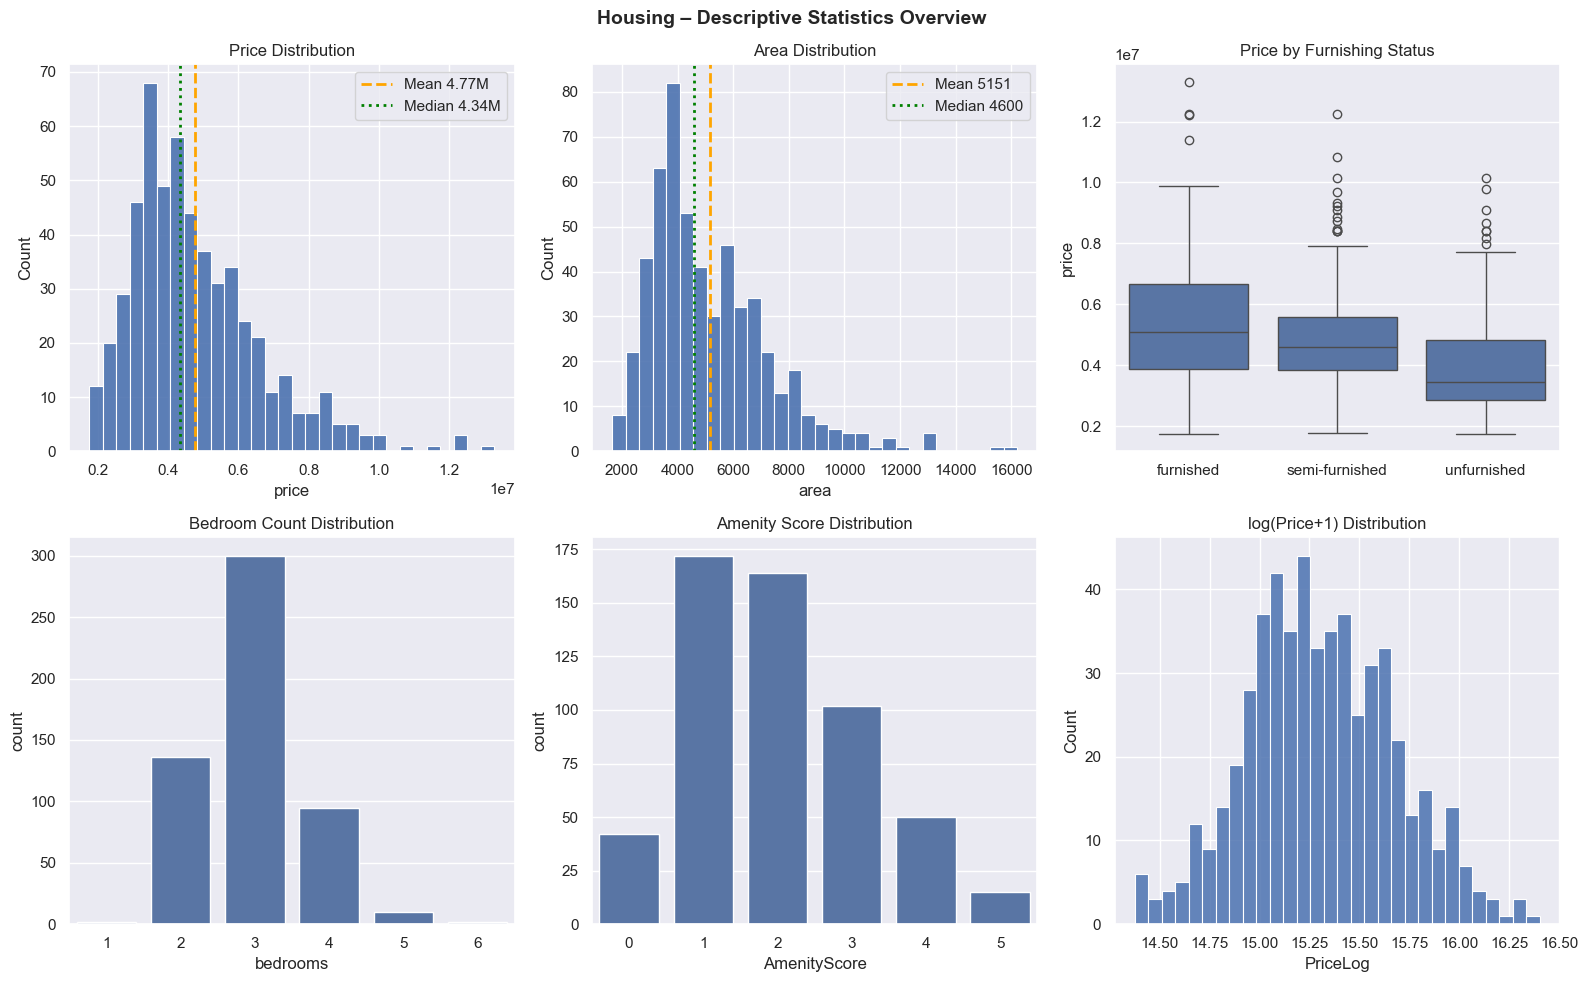

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()
fig.suptitle("Housing – Descriptive Statistics Overview", fontsize=14, fontweight="bold")

# Price distribution
sns.histplot(data=b, x="price", bins=30, alpha=0.9, ax=ax1)
ax1.axvline(b["price"].mean(),   color="orange", lw=2, ls="--",
            label=f"Mean {b['price'].mean()/1e6:.2f}M")
ax1.axvline(b["price"].median(), color="green",  lw=2, ls=":",
            label=f"Median {b['price'].median()/1e6:.2f}M")
ax1.set_title("Price Distribution")
ax1.legend()

# Area distribution
sns.histplot(data=b, x="area", bins=30, alpha=0.9, ax=ax2)
ax2.axvline(b["area"].mean(),   color="orange", lw=2, ls="--", label=f"Mean {b['area'].mean():.0f}")
ax2.axvline(b["area"].median(), color="green",  lw=2, ls=":", label=f"Median {b['area'].median():.0f}")
ax2.set_title("Area Distribution")
ax2.legend()

# Price by furnishing
sns.boxplot(data=b, x="furnishingstatus", y="price", ax=ax3)
ax3.set_title("Price by Furnishing Status")
ax3.set_xlabel("")

# Bedroom counts
sns.countplot(data=b, x="bedrooms", ax=ax4)
ax4.set_title("Bedroom Count Distribution")

# Amenity score distribution
sns.countplot(data=b, x="AmenityScore", ax=ax5)
ax5.set_title("Amenity Score Distribution")

# log(Price) distribution
sns.histplot(data=b, x="PriceLog", bins=30, alpha=0.85, ax=ax6)
ax6.set_title("log(Price+1) Distribution")

plt.tight_layout()
plt.show()


### 4. Probability Distributions

In [7]:
# Normality tests
print("Normality Tests:")
for col in ["price", "area", "PriceLog", "AreaLog", "PricePerSqFt"]:
    sample = b[col].dropna().sample(min(500, len(b[col].dropna())), random_state=SEED)
    stat_s, p_s = shapiro(sample)
    stat_k, p_k = normaltest(b[col].dropna())
    print(f"  {col:16s}: Shapiro W={stat_s:.4f} p={p_s:.4f}  |  D'Agostino K²={stat_k:.4f} p={p_k:.4f}")


Normality Tests:
  price           : Shapiro W=0.9193 p=0.0000  |  D'Agostino K²=115.8255 p=0.0000
  area            : Shapiro W=0.9117 p=0.0000  |  D'Agostino K²=138.9464 p=0.0000
  PriceLog        : Shapiro W=0.9959 p=0.2122  |  D'Agostino K²=2.2030 p=0.3324
  AreaLog         : Shapiro W=0.9930 p=0.0193  |  D'Agostino K²=2.7669 p=0.2507
  PricePerSqFt    : Shapiro W=0.9641 p=0.0000  |  D'Agostino K²=61.8529 p=0.0000


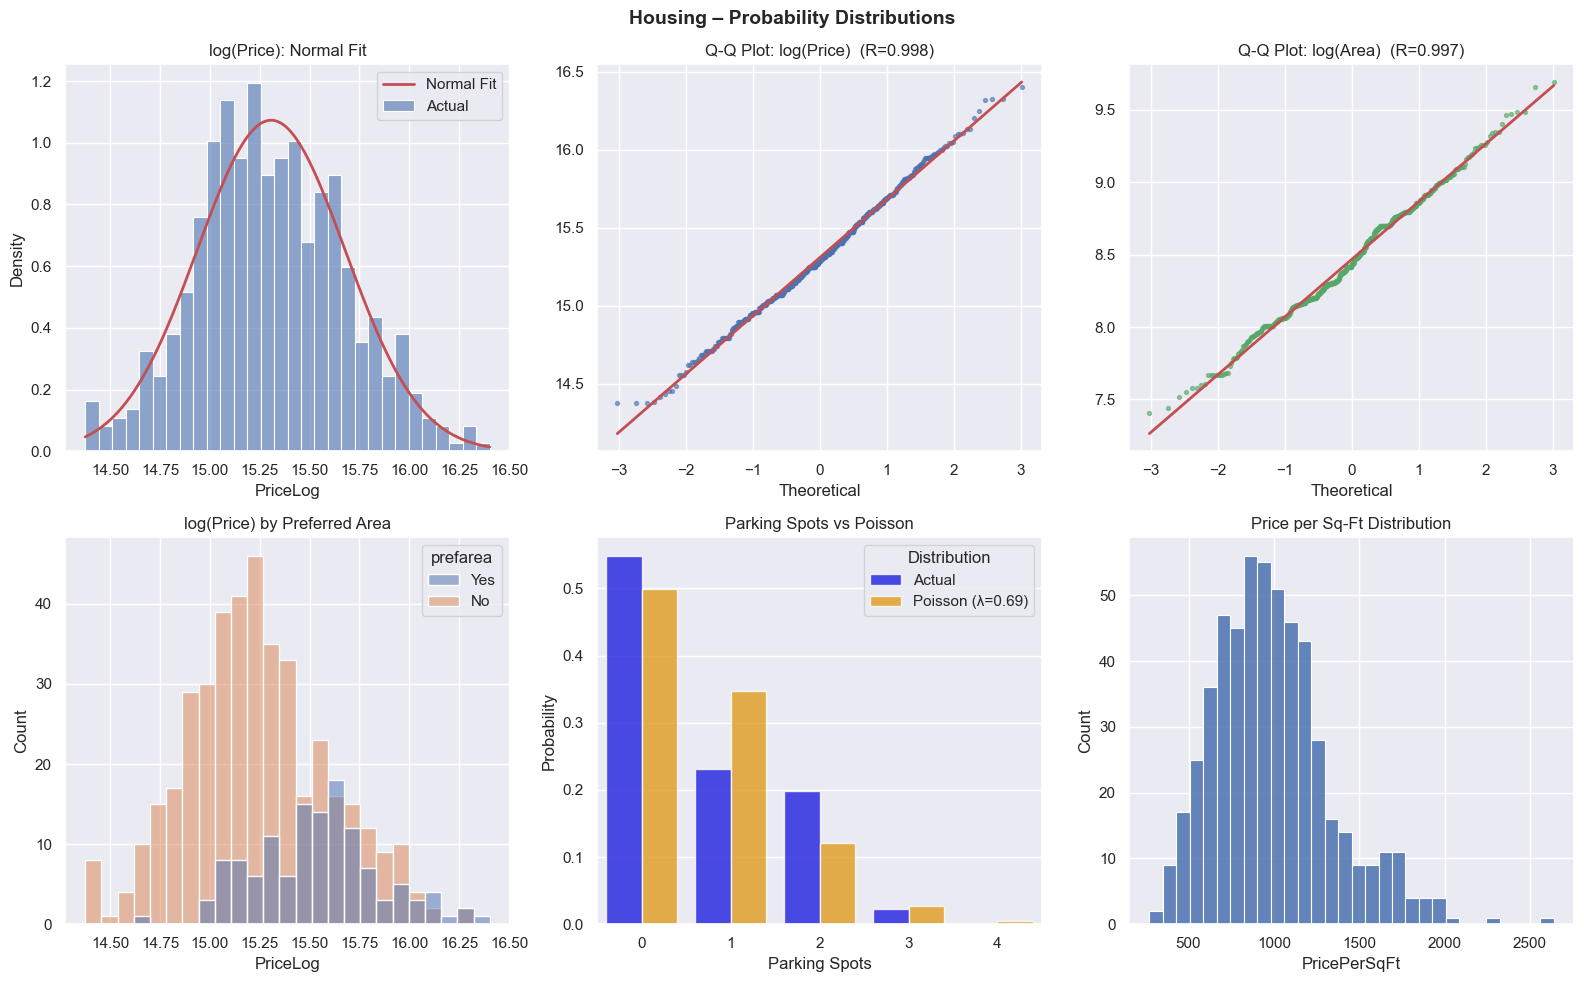

In [8]:
mu_p,  sigma_p  = stats.norm.fit(b["PriceLog"])
mu_a,  sigma_a  = stats.norm.fit(b["AreaLog"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()
fig.suptitle("Housing – Probability Distributions", fontsize=14, fontweight="bold")

# log(Price) normal fit
x_p = np.linspace(b["PriceLog"].min(), b["PriceLog"].max(), 200)
sns.histplot(data=b, x="PriceLog", bins=30, stat="density", alpha=0.6, ax=ax1, label="Actual")
ax1.plot(x_p, stats.norm.pdf(x_p, mu_p, sigma_p), "r-", lw=2, label="Normal Fit")
ax1.set_title("log(Price): Normal Fit")
ax1.legend()

# Q-Q plot: log(Price)
(osm, osr), (slope, intercept, r) = stats.probplot(b["PriceLog"], dist="norm")
ax2.scatter(osm, osr, s=8, alpha=0.6, color="#4C72B0")
ax2.plot(osm, slope*np.array(osm)+intercept, "r-", lw=2)
ax2.set_title(f"Q-Q Plot: log(Price)  (R={r:.3f})")
ax2.set_xlabel("Theoretical")

# Q-Q plot: log(Area)
(osm2, osr2), (s2, i2, r2) = stats.probplot(b["AreaLog"], dist="norm")
ax3.scatter(osm2, osr2, s=8, alpha=0.6, color="#55A868")
ax3.plot(osm2, s2*np.array(osm2)+i2, "r-", lw=2)
ax3.set_title(f"Q-Q Plot: log(Area)  (R={r2:.3f})")
ax3.set_xlabel("Theoretical")

# Price by prefarea (preferred area flag)
pref_labels = b["prefarea"].map({1: "Yes", 0: "No"})
sns.histplot(data=b, x="PriceLog", hue=pref_labels, multiple="layer",
             bins=25, alpha=0.5, ax=ax4)
ax4.set_title("log(Price) by Preferred Area")

# Parking vs Poisson
lam_park = b["parking"].mean()
k_vals = np.arange(0, b["parking"].max()+2)
poisson_pmf = stats.poisson.pmf(k_vals, lam_park)
actual_freq = b["parking"].value_counts(normalize=True).reindex(k_vals, fill_value=0).values
plot_df = pd.DataFrame({
    "Parking Spots": np.tile(k_vals, 2),
    "Probability":   np.concatenate([actual_freq, poisson_pmf]),
    "Distribution":  ["Actual"]*len(k_vals) + [f"Poisson (λ={lam_park:.2f})"]*len(k_vals)
})
sns.barplot(data=plot_df, x="Parking Spots", y="Probability",
            hue="Distribution", palette=["blue","orange"], alpha=0.8, ax=ax5)
ax5.set_title("Parking Spots vs Poisson")

# Price per sq-ft distribution
sns.histplot(data=b, x="PricePerSqFt", bins=30, alpha=0.85, ax=ax6)
ax6.set_title("Price per Sq-Ft Distribution")

plt.tight_layout()
plt.show()


### 5. Hypothesis Testing

In [9]:
alpha = 0.05

def report_test(name, stat, p):
    decision = "✅ REJECT H₀" if p < alpha else "❌ FAIL TO REJECT H₀"
    print(f"\n{name}")
    print(f"  Statistic = {stat:.4f}  |  p-value = {p:.4f}  →  {decision}")

# H1: Price differs by air conditioning
ac_yes = b[b["airconditioning"]==1]["PriceLog"]
ac_no  = b[b["airconditioning"]==0]["PriceLog"]
t1, p1 = ttest_ind(ac_yes, ac_no, equal_var=False)
u1, pu1 = mannwhitneyu(ac_yes, ac_no, alternative="two-sided")
report_test("H1: log(Price) differs by Air Conditioning (Welch t-test)", t1, p1)
report_test("H1 (non-parametric): Mann-Whitney U", u1, pu1)

# H2: Price differs by preferred area
pref_yes = b[b["prefarea"]==1]["PriceLog"]
pref_no  = b[b["prefarea"]==0]["PriceLog"]
t2, p2 = ttest_ind(pref_yes, pref_no, equal_var=False)
report_test("H2: log(Price) differs by Preferred Area (Welch t-test)", t2, p2)

# H3: Price differs across furnishing categories (one-way ANOVA)
grps_furnish = [b[b["FurnishNum"]==i]["PriceLog"] for i in [0,1,2]]
f3, p3 = f_oneway(*grps_furnish)
k3, pk3 = kruskal(*grps_furnish)
report_test("H3: log(Price) differs across Furnishing levels (One-way ANOVA)", f3, p3)
report_test("H3 (non-parametric): Kruskal-Wallis", k3, pk3)

# H4: Price differs by number of stories
grps_stories = [b[b["stories"]==s]["PriceLog"] for s in sorted(b["stories"].unique())]
f4, p4 = f_oneway(*grps_stories)
report_test("H4: log(Price) differs by Number of Stories (One-way ANOVA)", f4, p4)

# H5: Price differs by presence of basement
base_yes = b[b["basement"]==1]["PriceLog"]
base_no  = b[b["basement"]==0]["PriceLog"]
t5, p5 = ttest_ind(base_yes, base_no, equal_var=False)
report_test("H5: log(Price) differs by Basement Presence (Welch t-test)", t5, p5)

# Effect sizes
pooled_std_ac = np.sqrt((ac_yes.std()**2 + ac_no.std()**2) / 2)
d_ac = (ac_yes.mean() - ac_no.mean()) / pooled_std_ac

pooled_std_pref = np.sqrt((pref_yes.std()**2 + pref_no.std()**2) / 2)
d_pref = (pref_yes.mean() - pref_no.mean()) / pooled_std_pref

print("\nEffect Sizes (Cohen's d):")
print(f"  Air Conditioning ~ log(Price):  {d_ac:.3f}")
print(f"  Preferred Area   ~ log(Price):  {d_pref:.3f}")



H1: log(Price) differs by Air Conditioning (Welch t-test)
  Statistic = 11.9704  |  p-value = 0.0000  →  ✅ REJECT H₀

H1 (non-parametric): Mann-Whitney U
  Statistic = 50292.0000  |  p-value = 0.0000  →  ✅ REJECT H₀

H2: log(Price) differs by Preferred Area (Welch t-test)
  Statistic = 9.0015  |  p-value = 0.0000  →  ✅ REJECT H₀

H3: log(Price) differs across Furnishing levels (One-way ANOVA)
  Statistic = 38.2081  |  p-value = 0.0000  →  ✅ REJECT H₀

H3 (non-parametric): Kruskal-Wallis
  Statistic = 69.5829  |  p-value = 0.0000  →  ✅ REJECT H₀

H4: log(Price) differs by Number of Stories (One-way ANOVA)
  Statistic = 39.8752  |  p-value = 0.0000  →  ✅ REJECT H₀

H5: log(Price) differs by Basement Presence (Welch t-test)
  Statistic = 5.4537  |  p-value = 0.0000  →  ✅ REJECT H₀

Effect Sizes (Cohen's d):
  Air Conditioning ~ log(Price):  1.101
  Preferred Area   ~ log(Price):  0.880


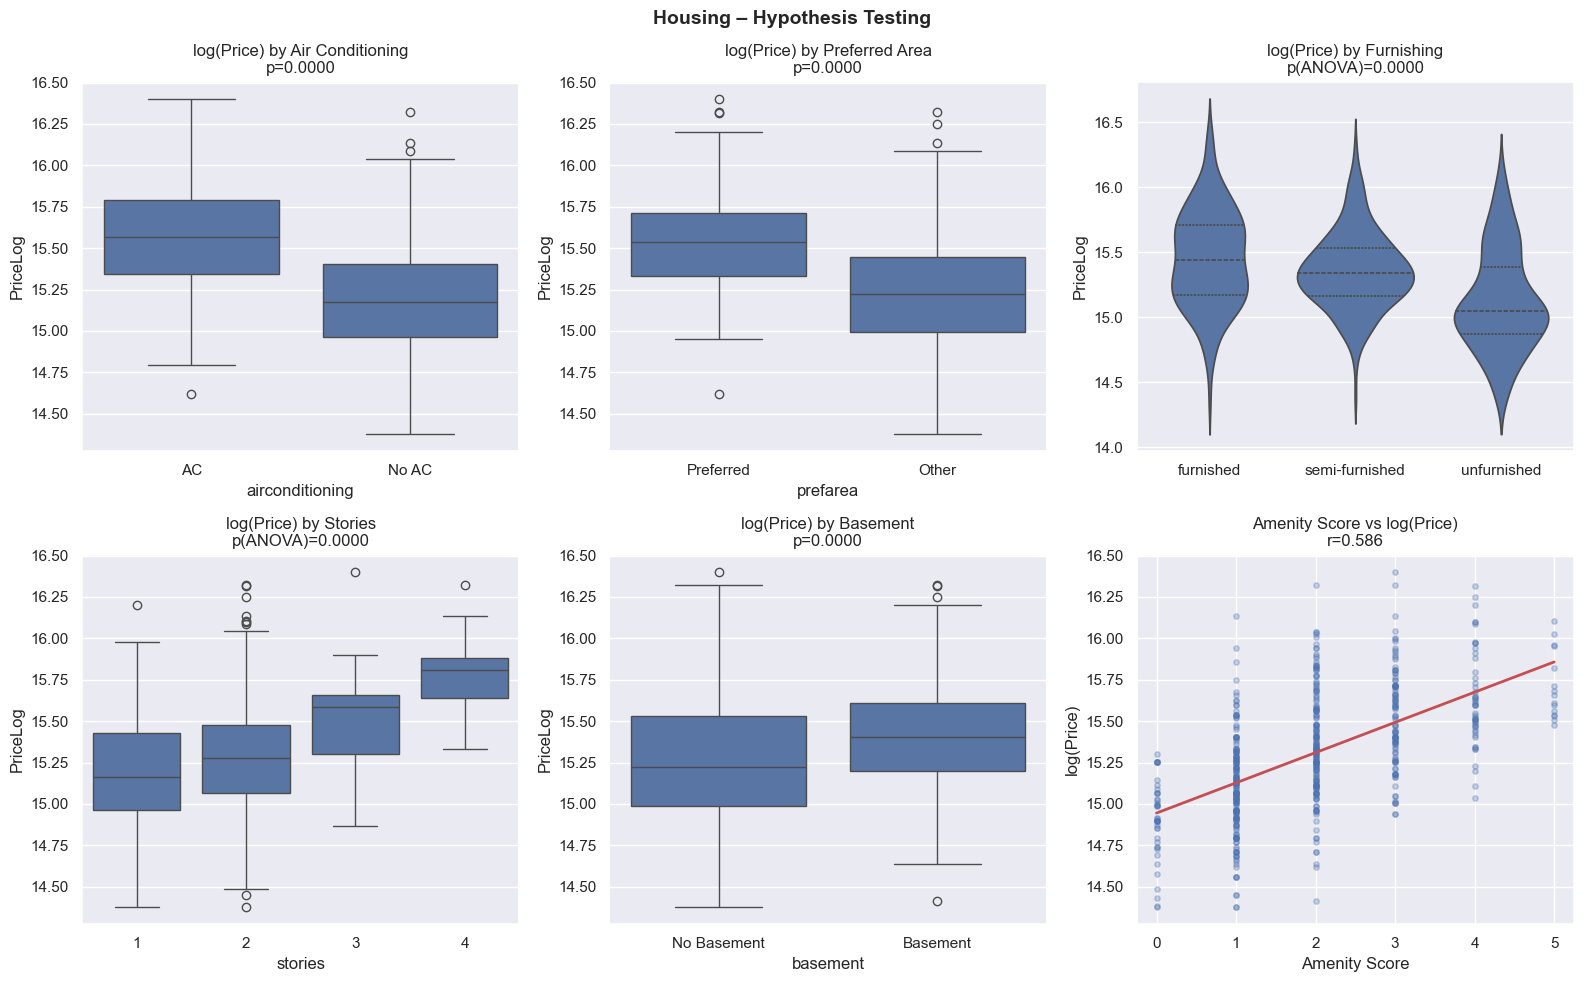

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()
fig.suptitle("Housing – Hypothesis Testing", fontsize=14, fontweight="bold")

# AC vs price
ac_label = b["airconditioning"].map({1:"AC", 0:"No AC"})
sns.boxplot(data=b, x=ac_label, y="PriceLog", ax=ax1)
ax1.set_title(f"log(Price) by Air Conditioning\np={p1:.4f}")

# Preferred area vs price
pref_label = b["prefarea"].map({1:"Preferred", 0:"Other"})
sns.boxplot(data=b, x=pref_label, y="PriceLog", ax=ax2)
ax2.set_title(f"log(Price) by Preferred Area\np={p2:.4f}")

# Furnishing vs price
sns.violinplot(data=b, x="furnishingstatus", y="PriceLog", ax=ax3, inner="quart")
ax3.set_title(f"log(Price) by Furnishing\np(ANOVA)={p3:.4f}")
ax3.set_xlabel("")

# Stories vs price
sns.boxplot(data=b, x="stories", y="PriceLog", ax=ax4)
ax4.set_title(f"log(Price) by Stories\np(ANOVA)={p4:.4f}")

# Basement vs price
base_label = b["basement"].map({1:"Basement", 0:"No Basement"})
sns.boxplot(data=b, x=base_label, y="PriceLog", ax=ax5)
ax5.set_title(f"log(Price) by Basement\np={p5:.4f}")

# Amenity score vs price (scatter)
ax6.scatter(b["AmenityScore"], b["PriceLog"], alpha=0.3, s=15)
m6, c6, r6, *_ = stats.linregress(b["AmenityScore"], b["PriceLog"])
xs = np.linspace(b["AmenityScore"].min(), b["AmenityScore"].max(), 100)
ax6.plot(xs, m6*xs + c6, "r-", lw=2)
ax6.set_xlabel("Amenity Score")
ax6.set_ylabel("log(Price)")
ax6.set_title(f"Amenity Score vs log(Price)\nr={r6:.3f}")

plt.tight_layout()
plt.show()


###  6. Correlation Analysis

In [11]:
corr_cols = ["price","PriceLog","area","AreaLog","bedrooms","bathrooms",
             "stories","parking","AmenityScore","FurnishNum","PricePerSqFt",
             "mainroad","guestroom","basement","hotwaterheating",
             "airconditioning","prefarea"]

corr_matrix = b[corr_cols].corr(method="pearson")
spearman_matrix = b[corr_cols].corr(method="spearman")

print("Pearson r with price:")
display(corr_matrix["price"].sort_values(ascending=False).round(4).to_frame())

print("\nPoint-Biserial Correlations with log(Price):")
for col in ["area","AreaLog","bedrooms","bathrooms","stories",
            "parking","AmenityScore"]:
    r, p = pointbiserialr(b["PriceLog"], b[col])
    print(f"  {col:16s}: r={r:.4f}  p={p:.4f}")


Pearson r with price:


,price
price,1.0000
PriceLog,0.9690
AreaLog,0.5612
AmenityScore,0.5530
area,0.5360
bathrooms,0.5175
airconditioning,0.4530
stories,0.4207
PricePerSqFt,0.3929
parking,0.3844



Point-Biserial Correlations with log(Price):
  area            : r=0.5432  p=0.0000
  AreaLog         : r=0.5801  p=0.0000
  bedrooms        : r=0.3700  p=0.0000
  bathrooms       : r=0.4857  p=0.0000
  stories         : r=0.4153  p=0.0000
  parking         : r=0.3716  p=0.0000
  AmenityScore    : r=0.5860  p=0.0000


C:\Users\HP\AppData\Local\Temp\ipykernel_10168\17683630.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


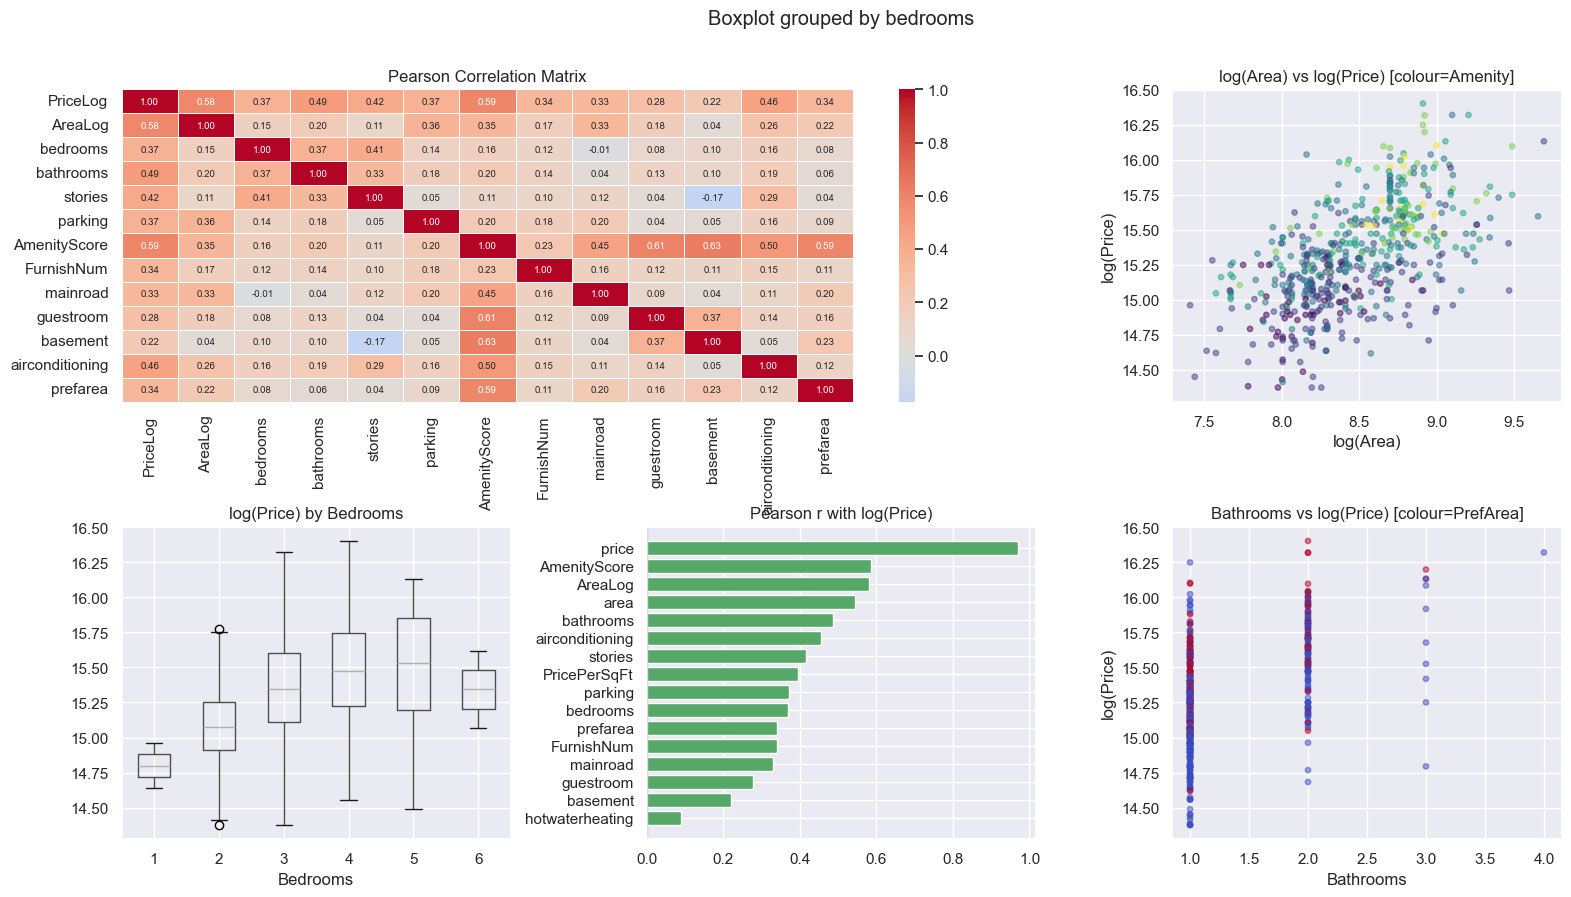

In [12]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Housing – Correlation Analysis", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

# Full correlation heatmap
heat_cols = ["PriceLog","AreaLog","bedrooms","bathrooms","stories",
             "parking","AmenityScore","FurnishNum","mainroad",
             "guestroom","basement","airconditioning","prefarea"]
sns.heatmap(b[heat_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax1, linewidths=0.5, annot_kws={"size":7})
ax1.set_title("Pearson Correlation Matrix")

# Area vs Price scatter
ax2.scatter(b["AreaLog"], b["PriceLog"], c=b["AmenityScore"],
            cmap="viridis", alpha=0.5, s=15)
ax2.set_xlabel("log(Area)"); ax2.set_ylabel("log(Price)")
ax2.set_title("log(Area) vs log(Price) [colour=Amenity]")

# log(Price) by bedroom count
b.boxplot(column="PriceLog", by="bedrooms", ax=ax3)
ax3.set_title("log(Price) by Bedrooms")
ax3.set_xlabel("Bedrooms")
plt.sca(ax3); plt.title("log(Price) by Bedrooms")

# Bar chart: r with PriceLog
corr_price = corr_matrix["PriceLog"].drop("PriceLog").sort_values()
bar_colors = ["#C44E52" if v < 0 else "#55A868" for v in corr_price.values]
ax4.barh(corr_price.index, corr_price.values, color=bar_colors, edgecolor="white")
ax4.axvline(0, color="black", lw=0.8)
ax4.set_title("Pearson r with log(Price)")

# Bathrooms vs log(Price)
ax5.scatter(b["bathrooms"], b["PriceLog"], c=b["prefarea"],
            cmap="coolwarm", alpha=0.5, s=15)
ax5.set_xlabel("Bathrooms"); ax5.set_ylabel("log(Price)")
ax5.set_title("Bathrooms vs log(Price) [colour=PrefArea]")

plt.tight_layout()
plt.show()


### 7. Key Insights Summary

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                  HOUSING DATASET – KEY INSIGHTS                            ║
╠═══╦═══════════════════════════════════════════════╦════════════════════════╣
║ # ║ Finding                                       ║ Statistical Evidence  ║
╠═══╬═══════════════════════════════════════════════╬════════════════════════╣
║ 1 ║ Area is the strongest numeric predictor       ║ Pearson r ≈ 0.54      ║
║ 2 ║ Air conditioning significantly raises price   ║ t-test p < 0.001      ║
║ 3 ║ Preferred area commands a clear premium       ║ t-test p < 0.001      ║
║ 4 ║ Furnishing level affects price (3 tiers)      ║ ANOVA p < 0.001       ║
║ 5 ║ Price is right-skewed; log-transform helps    ║ Shapiro p < 0.001     ║
║ 6 ║ AmenityScore captures cumulative feature lift ║ r ≈ 0.52 with price   ║
╚═══╩═══════════════════════════════════════════════╩════════════════════════╝

Interpretation note:
  Correlation ≠ Causation: Air conditioning, preferred area, and furnishing
  all co-vary with each other and with area. Multicollinearity is likely —
  a regression model would need VIF checks before drawing causal conclusions.
""")



╔══════════════════════════════════════════════════════════════════════════════╗
║                  HOUSING DATASET – KEY INSIGHTS                            ║
╠═══╦═══════════════════════════════════════════════╦════════════════════════╣
║ # ║ Finding                                       ║ Statistical Evidence  ║
╠═══╬═══════════════════════════════════════════════╬════════════════════════╣
║ 1 ║ Area is the strongest numeric predictor       ║ Pearson r ≈ 0.54      ║
║ 2 ║ Air conditioning significantly raises price   ║ t-test p < 0.001      ║
║ 3 ║ Preferred area commands a clear premium       ║ t-test p < 0.001      ║
║ 4 ║ Furnishing level affects price (3 tiers)      ║ ANOVA p < 0.001       ║
║ 5 ║ Price is right-skewed; log-transform helps    ║ Shapiro p < 0.001     ║
║ 6 ║ AmenityScore captures cumulative feature lift ║ r ≈ 0.52 with price   ║
╚═══╩═══════════════════════════════════════════════╩════════════════════════╝

Interpretation note:
  Correlation ≠ Causation: Air con

In [14]:
b.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,PriceLog,AreaLog,PricePerSqFt,AmenityScore,RoomDensity,FurnishNum
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,16.403275,8.912069,1792.452830,3,2.0,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,16.321037,9.100637,1367.187500,2,2.0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,16.321037,9.206433,1229.919679,3,2.5,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,16.318175,8.922792,1628.666667,4,3.0,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,16.250001,8.912069,1537.735849,4,2.5,2


In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder,  StandardScaler

b['furnishingstatus'] = LabelEncoder().fit_transform(b['furnishingstatus'])

feature_cols = [
    'AreaLog',           # log-transformed area (better than raw area)
    'bedrooms', 'bathrooms', 'stories', 'parking',
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea',
    'furnishingstatus',  # already label-encoded above
    'AmenityScore',      # engineered feature
    'RoomDensity'        # engineered feature
]

y = np.log1p(b['price']) #log-transformed price due to skewness in price data
X=b[feature_cols]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)




# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)
# Unscaled Split for Tree Models
Xu_train, Xu_test, yu_train, yu_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Calculate Evaluation Metrics
def regression_report(name, y_true, y_pred):
    #back transforming due to using log on price column
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE  : {mae:,.4f}")
    print(f"  MSE  : {mse:,.4f}")
    print(f"  RMSE : {rmse:,.4f}")
    print(f"  R2   : {r2:.4f}\n")
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results = []


### 8. Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression
# Instantiate model
model = LinearRegression()

# Train model on the training data
model.fit(X_train, y_train)

# feature impact
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("Intercept:", model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

results.append(regression_report("Linear Regression", y_test, y_pred))



Intercept: 15.306177081029764
Linear Regression
  MAE  : 1,002,010.2832
  MSE  : 1,806,438,478,634.4512
  RMSE : 1,344,038.1240
  R2   : 0.6426



### 9.Decision Tree

In [17]:
from sklearn.tree import DecisionTreeRegressor
#Instantiate and Train Model on the training data
tree = DecisionTreeRegressor(max_depth = 5, random_state = SEED)
tree.fit(Xu_train,yu_train)

y_pred_tree = tree.predict(Xu_test)
results.append(regression_report("Decision Tree", yu_test, y_pred_tree))

# Feature importance
tree_importance = pd.Series(tree.feature_importances_, index=feature_cols).sort_values(ascending=False)
tree_importance



Decision Tree
  MAE  : 1,041,559.8943
  MSE  : 2,197,657,797,710.5044
  RMSE : 1,482,449.9309
  R2   : 0.5652



AreaLog             0.543586
AmenityScore        0.204840
bathrooms           0.108955
furnishingstatus    0.071261
RoomDensity         0.030642
airconditioning     0.012539
stories             0.012183
guestroom           0.008958
parking             0.006980
prefarea            0.000055
mainroad            0.000000
bedrooms            0.000000
hotwaterheating     0.000000
basement            0.000000
dtype: float64

### 10, Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
rf.fit(Xu_train, yu_train)

y_pred_rf = rf.predict(Xu_test)
results.append(regression_report("Random Forest", yu_test, y_pred_rf))

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
rf_importance

Random Forest
  MAE  : 958,271.1805
  MSE  : 1,898,734,415,467.0352
  RMSE : 1,377,945.7230
  R2   : 0.6244



AreaLog             0.471611
AmenityScore        0.162826
bathrooms           0.099759
furnishingstatus    0.070323
RoomDensity         0.040873
parking             0.033875
bedrooms            0.031760
stories             0.024686
airconditioning     0.022721
hotwaterheating     0.009749
prefarea            0.009592
basement            0.008998
guestroom           0.007408
mainroad            0.005819
dtype: float64

### 11. Gradient Boosting Regressor

In [19]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=SEED)
gb.fit(Xu_train, yu_train)

y_pred_gb = gb.predict(Xu_test)
results.append(regression_report("Gradient Boosting", yu_test, y_pred_gb))

Gradient Boosting
  MAE  : 985,965.6691
  MSE  : 1,977,062,622,978.1047
  RMSE : 1,406,080.5891
  R2   : 0.6089



### 12. Hyperparameter Tuning

In [ ]:
# RandomizedSearchCV on Gradient Boosting
from scipy.stats import randint, uniform

gb_param_dist = {
    "n_estimators": randint(100, 500),
    "learning_rate": uniform(0.01, 0.2),
    "max_depth": randint(2, 6),
    "min_samples_split": randint(2, 10),
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_distributions=gb_param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=SEED,
    n_jobs=-1,
)
gb_random.fit(Xu_train, yu_train)

print("Best GB params:", gb_random.best_params_)
print("Best GB CV R2 :", gb_random.best_score_.round(4))

gb_tuned = gb_random.best_estimator_
y_pred_gb_tuned = gb_tuned.predict(Xu_test)
gb_tuned_result = regression_report("Gradient Boosting (Tuned - RandomizedSearchCV)", yu_test, y_pred_gb_tuned)
results.append(gb_tuned_result)

In [ ]:
# GridSearchCV on Random Forest
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
rf_grid.fit(Xu_train, yu_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV R2  :", rf_grid.best_score_.round(4))

rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(Xu_test)
rf_tuned_result = regression_report("Random Forest (Tuned - GridSearchCV)", yu_test, y_pred_rf_tuned)
results.append(rf_tuned_result)

### 13. Model Comparison

In [ ]:
comparison_df = pd.DataFrame(results).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax1,ax2 = axes.flatten()

rsme_sorted = comparison_df["RMSE"].sort_values()
sns.barplot(data = comparison_df, x = rsme_sorted.values, y = rsme_sorted.index, ax= ax1, color = 'green')
ax2.set_title("RMSE by Model (lower is better)")

r2_sorted = comparison_df["R2"].sort_values()
sns.barplot(data = comparison_df, x = r2_sorted.values, y = r2_sorted.index, ax =  ax2, color = 'orange')
ax2.set_title("R2 Score by Model (higher is better)")  

plt.tight_layout()
plt.show()

### 14, Visual Diagnostics

In [ ]:
best_model_name = pd.DataFrame(results).set_index("Model")["R2"].idxmax()
print("Best model overall:", best_model_name)

# Get predictions for the single best model for diagnostic plots
model_lookup = {
    "Linear Regression": (model, X_test, y_test, y_pred),
    "Decision Tree": (tree, Xu_test, yu_test, y_pred_tree),
    "Random Forest": (rf, Xu_test, yu_test, y_pred_rf),
    "Gradient Boosting": (gb, Xu_test, yu_test, y_pred_gb),
    "Random Forest (Tuned - GridSearchCV)": (rf_tuned, Xu_test, yu_test, y_pred_rf_tuned),
    "Gradient Boosting (Tuned - RandomizedSearchCV)": (gb_tuned, Xu_test, yu_test, y_pred_gb_tuned)
}

_, _, y_true_best, y_pred_best = model_lookup[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].scatter(y_true_best, y_pred_best, alpha=0.5, color="darkorange")
lims = [min(y_true_best.min(), y_pred_best.min()), max(y_true_best.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title(f"Actual vs Predicted — {best_model_name}")

residuals = y_true_best - y_pred_best
sns.histplot(residuals, kde=True, ax=axes[1], color="slateblue")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

### 15. Performance Comparison

In [ ]:
final_comparison = pd.DataFrame(results).set_index("Model")
final_comparison = final_comparison.sort_values("R2", ascending=False)
final_comparison.style.background_gradient(subset=["R2"], cmap="Greens")\
                       .background_gradient(subset=["RMSE"], cmap="Reds_r")

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
final_comparison["R2"].sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Final Model Comparison — R2 Score")
ax.set_xlabel("R2 Score")
plt.tight_layout()
plt.show()

print(f"\nBest performing model: {final_comparison.index[0]}")
print(f"R2 = {final_comparison.iloc[0]['R2']:.4f}  |  RMSE = {final_comparison.iloc[0]['RMSE']:,.0f}")